In [ ]:
user_data = [
    {
        "id": 1,
        "user": {
            "name": "Alice",
            "roles": [
                "admin",
                "editor"
            ],
            "profile": {
                "age": 30,
                "address": {
                    "street": "Main St",
                    "city": "Wonderland",
                    "zip": "12345"
                },
                "preferences": {
                    "notifications": True,
                    "theme": "dark"
                }
            }
        },
        "activities": [
            {
                "type": "login",
                "timestamp": "2024-06-01T08:00:00Z"
            },
            {
                "type": "edit",
                "timestamp": "2024-06-04T09:00:00Z",
                "details": {
                    "document": "report.docx",
                    "changes": 5
                }
            }
        ]
    },
    {
        "id": 2,
        "user": {
            "name": "Bob",
            "roles": [
                "viewer"
            ],
            "profile": {
                "age": 25,
                "address": {
                    "street": "456 Side St",
                    "city": "Builderland",
                    "zip": "67890"
                },
                "preferences": {
                    "notifications": False,
                    "theme": "light"
                }
            }
        },
        "activities": [
            {
                "type": "login",
                "timestamp": "2024-06-02T10:00:00Z"
            },
            {
                "type": "view",
                "timestamp": "2024-06-02T10:05:00Z",
                "details": {
                    "document": "manual.pdf"
                }
            }
        ]
    },
    {
        "id": 3,
        "user": {
            "name": "Charlie",
            "roles": [
                "editor",
                "viewer"
            ],
            "profile": {
                "age": 28,
                "address": {
                    "street": "789 Up St",
                    "city": "Chocoland",
                    "zip": "11223"
                },
                "preferences": {
                    "notifications": True,
                    "theme": "dark"
                }
            }
        },
        "activities": [
            {
                "type": "login",
                "timestamp": "2024-06-03T11:00:00Z"
            },
            {
                "type": "edit",
                "timestamp": "2024-06-03T11:30:00Z",
                "details": {
                    "document": "summary.txt",
                    "changes": 3
                }
            },
            {
                "type": "view",
                "timestamp": "2024-06-03T12:00:00Z",
                "details": {
                    "document": "overview.pdf"
                }
            }
        ]
    }
]

In [ ]:
# Get all user names from the training data.

[data["user"]["name"] for data in user_data]

In [ ]:
# Get the record where id = 2.

[data for data in user_data if data["id"] == 1]

In [ ]:
# Count the total number of records in the training data.

len(user_data)

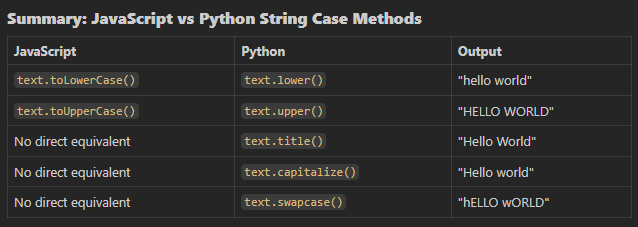

In [ ]:
# Get Alice's age.

record = next((data for data in user_data if str(data["user"]["name"]).lower() == "Alice".lower()))
record["user"]["profile"]["age"]

In [ ]:
# Get Bob's address (complete address object).

# Using next()
record = next((data for data in user_data if str(data["user"]["name"]).lower() == "Bob".lower()))
record["user"]["profile"]["address"]

# Using filter()
f_record = list(filter(lambda data: data["user"]["name"] == "Alice", user_data))[0]
f_record["user"]["profile"]["address"]

In [ ]:
# Get all users who have notifications enabled.

[data for data in user_data if data["user"]["profile"]["preferences"]["notifications"] == True]

In [ ]:
# Find the oldest user's name

sorted(user_data, key=lambda data: data["user"]["profile"]["age"], reverse=True)[0]["user"]["name"]

# Find the youngest user's age

sorted(user_data, key=lambda data: data["user"]["profile"]["age"])[0]["user"]["name"]

In [ ]:
# Get all users who have "admin" or "editor" role

[data for data in user_data if "admin" in data["user"]["roles"] or "editor" in data["user"]["roles"]]

In [ ]:
# Get all login timestamps across all users

def get_login_timestamps(user_data):
    for data in user_data:
        for act in data.get("activities", []):
            if act.get("type") == "login":
                ts = act.get("timestamp")
                if ts is not None:
                    yield ts
        
print(list(get_login_timestamps(user_data=user_data)))

In [ ]:
# Get all edit activities (type = "edit") from all users

def get_edit_activities(user_data):
    for data in user_data:
        for act in data.get("activities", []):
            if act.get("type", None) == "edit":
                yield act
                
print(list(get_edit_activities(user_data)))

### 💡.join()

In [ ]:
# Find who edited "report.docx"

def find_who_edited_report_file(user_data):
    for data in user_data:
        for act in data.get("activities", []):
            if act.get("type", None) == "edit":
                details = act.get("details", None)
                if details and details.get("document", None) == "report.docx":
                    yield data["user"]["name"]
                    
edited_users = list(find_who_edited_report_file(user_data))
print(f"The report.docx are edited by {", ".join(edited_users)}")

### 💡 .isinstance()

In [ ]:
# Get all the documents that are viewed

def get_viewed_docs(user_data: list):
    for data in user_data:
        for act in data.get("activities", []):
            if act.get("type", None) == "view":
                view_type_details = act.get("details", None)
                if isinstance(view_type_details, dict):
                    yield view_type_details.get("document", None)
                    
viewed_docs = list(get_viewed_docs(user_data))
print(f"The viewed documents are {", ".join(viewed_docs)}")

### 💡 Generator Expression vs. List Comprehension

In [ ]:
# A generator in Python is a special type of iterator that produces values one at a time, 
# only as needed, instead of creating and storing all values in memory at once. 
# This makes generators memory efficient and suitable for working with large data or streams. 
# You create generators using functions with yield or with generator expressions using parentheses ().

# Generator expression (creates a generator)
gen = (x * x for x in range(5))

# List comprehension (creates a list)
lst = [x * x for x in range(5)]

### 💡 Generator & max()

In [ ]:
# Get the latest activity timestamp across all users

from datetime import datetime

all_activities = (act for data in user_data for act in data.get("activities", []))

latest_act = max(
    all_activities,
    key=lambda act: datetime.strptime(act["timestamp"], "%Y-%m-%dT%H:%M:%SZ"),
    default=None
)

if latest_act:
    print(f"The latest activity timestamp across all users is {latest_act['timestamp']}")
else:
    print("No activities found.")

In [ ]:
# Get users who live in the cities starts with "wonder"

result = filter(
    lambda data: (
        data.get("user", {}).get("profile", {}).get("address", {}).get("city")
        and str(data["user"]["profile"]["address"]["city"]).lower().startswith("wonder")
    ),
    user_data
)

print(list(result))

In [ ]:
# Find users who have made more than 2 activities

result = filter(lambda data: len(data.get("activities", [])) > 2, user_data)

print(list(result))

### 💡 any()

In [ ]:
# Get users who have both made edits and views

import json

result = [data for data in user_data if any(act["type"] == "edit" or act["type"] == "view" for act in data.get("activities", []))]

print(json.dumps(result, indent=4))

In [ ]:
# Find activities that happened on June 2nd, 2024

import json

result = [act for data in user_data for act in data.get("activities", []) if "2024-06-02" in act.get("timestamp", "")]

print(json.dumps(result, indent=4))


In [ ]:
# Create a list of all unique activity types across all users

results = [act.get("type", "") for data in user_data for act in data.get("activities", [])]
unique_acts = list(set(results))

print(f"The unique activities are {", ".join(unique_acts)}.")

In [ ]:
# Get a list of all cities where users live

results = [data.get("user", {}).get("profile", {}).get("address", {}).get("city", None) for data in user_data]
cities_list = list(set(results))

print(f"Here are the cities list - {", ".join(cities_list)}.")

In [ ]:
# Create a dictionary mapping user names to their ages

result = [{"name": data.get("user", {}).get("name", None), "age": data.get("user", {}).get("profile", {}).get("age", None)} for data in user_data]

print(result)

### 💡 sum()

In [ ]:
# Get the total number of changes made in all edit activities

results = [act.get("details", {}).get("changes", 0) for data in user_data for act in data.get("activities", []) if act.get("type") == "edit"]

print(sum(results))

In [ ]:
# Find which user made the most document changes

all_users = ({**act, "name": data.get("user", {}).get("name", None)} for data in user_data for act in data.get("activities", []) if act.get("type", None) == "edit")

final_user = max(
    all_users,
    key = lambda usr: usr["details"]["changes"],
    default=None
)

print(f"{final_user.get("name", "")} is the user made the most document changes.")

### 💡 any() & .isdigit()

In [ ]:
# Get all street addresses that contain numbers

[{**data["user"]["profile"]["address"]} for data in user_data if any(str(adrs).isdigit() for adrs in data.get("user", {}).get("profile", {}).get("address", {}).get("street", ""))]